# Examining Wall Bounce Behavior

In [1]:
#First import the various libraries needed
import sys
sys.path.append('/storage/home/hcoda1/9/dmathews33/Spin-tracking/scripts')
import nedmSim
import numpy as np
import matplotlib.pyplot as plt

In [17]:
tf = 500.0
tout = 1.0
numParticles = 65536
seed = 0

parameters = {}
parameters['particle'] = 'neutron' #choose particle type
parameters['dist'] = 'C' #velocity distribution method
parameters['T']='0.4' #set the temperature if using the distribution = 'M' option
parameters['gas_coll']='false' #are we doing phonon collisions? yes for helium-3 usually
parameters['diffuse']='0.1' #diffuse collisions? 0 = specular, 1 = diffuse, 0.5 is 50% diffuse, etc
parameters['gravity']='true' #gravity on or off?
parameters['B0'] = '3.0e-6, 0, 0' #magnetic field
parameters['numParticles'] = str(numParticles) #number of particles
parameters['numPerGPUBlock'] = '256' #number of particles per GPU block, does nothing on CPU
parameters['t0']='0.0' #start time of the simulation
parameters['tf']=str(tf) #stop time of the simulation
parameters['ioutInt']=str(tout) #output interval
parameters['a']= '0' #'19.1024180e-6' #driving field amplitude
parameters['w']='0' #'3000.0' #driving field frequency
parameters['h']='1e-5' #starting step size
parameters['keepStepSize'] = 'false' #do we remember the step size between function calls
parameters['fixedStepSize'] = 'false' #is the step size for spin integration fixed?
parameters['rtol'] = '1.0e-12' #relative precision desired for spin integration
parameters['atol'] = '1.0e-12' #absolute precision desired for spin integration
parameters['hmax'] = '1.0' #largest step size allowed for spin integration
parameters['hmin'] = '1.0e-9' #smallest step size allowed for spin integration
parameters['seed'] = str(seed) #random number seed for the first particle
parameters['integratorType'] = '-1' #the spin integration method

In [18]:
filename = 'neutronTest.txt'
parameters['V'] = '5.0'
parameters['diffuse'] = '0.10'
nedmSim.writeParameterFile(filename, parameters)
outputFile = '/storage/home/hcoda1/9/dmathews33/scratch/precisionTest64bit.out'
!~/Spin-tracking/bit64main {filename} {outputFile} > diffuse.txt
resultsDiffuse = nedmSim.readInOutputFile(outputFile, pad=3)

parameters['V'] = '5.0'
parameters['diffuse'] = '0'
nedmSim.writeParameterFile(filename, parameters)
outputFile = '/storage/home/hcoda1/9/dmathews33/scratch/precisionTest64bit.out'
!~/Spin-tracking/bit64main {filename} {outputFile} > specular.txt
resultsSpecular = nedmSim.readInOutputFile(outputFile, pad=3)

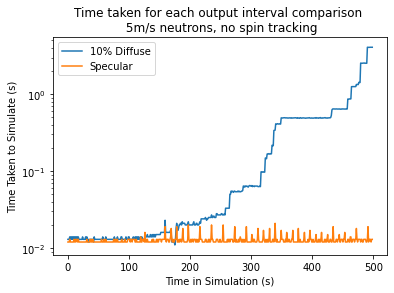

In [19]:
diffuseTimes = np.loadtxt('diffuse.txt', skiprows=2, dtype=float, usecols=(-1))/1000
specularTimes = np.loadtxt('specular.txt', skiprows=2, dtype=float, usecols=(-1))/1000
xvals = np.arange(len(diffuseTimes[:-1]))
plt.plot(xvals, diffuseTimes[:-1], label='10% Diffuse')
plt.plot(xvals, specularTimes[:-1], label='Specular')
plt.yscale('log')
plt.ylabel('Time Taken to Simulate (s)')
plt.xlabel('Time in Simulation (s)')
plt.legend()
plt.title("Time taken for each output interval comparison \n 5m/s neutrons, no spin tracking")
plt.show()

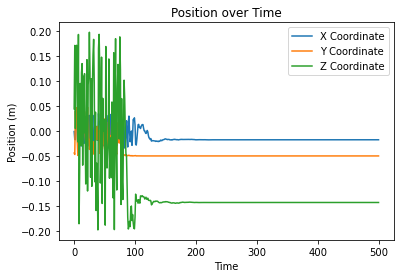

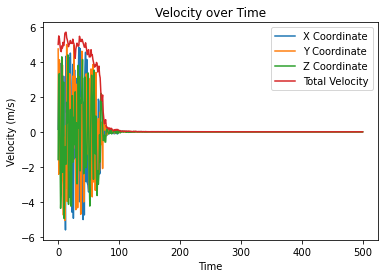

In [20]:
badParticle = np.argmax(resultsDiffuse[1]['n_bounce'][-1,:])
path = resultsDiffuse[1]['x'][:,badParticle,:]
time = np.arange(path.shape[0])
plt.plot(time, path[:,0], label='X Coordinate')
plt.plot(time, path[:,1], label='Y Coordinate')
plt.plot(time, path[:,2], label='Z Coordinate')
plt.legend()
plt.xlabel("Time")
plt.ylabel('Position (m)')
plt.title('Position over Time')
plt.show()

path = resultsDiffuse[1]['v'][:,badParticle,:]
time = np.arange(path.shape[0])
plt.plot(time, path[:,0], label='X Coordinate')
plt.plot(time, path[:,1], label='Y Coordinate')
plt.plot(time, path[:,2], label='Z Coordinate')
plt.plot(time, np.sqrt(np.sum(np.square(path), axis=1)), label='Total Velocity')
plt.legend()
plt.xlabel("Time")
plt.ylabel('Velocity (m/s)')
plt.title('Velocity over Time')
plt.show()

In [30]:
totalEnergy = (resultsDiffuse[1]['x'][:,:,1] - resultsDiffuse[0]['L'][1]/2.0) *-9.8
totalEnergy += 0.5 * np.sum(np.square(resultsDiffuse[1]['v']), axis=2)

In [31]:
totalEnergy.shape

(501, 65536)

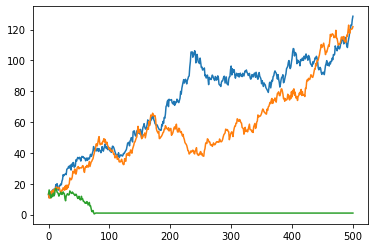

In [32]:
plt.plot(totalEnergy[:,0])
plt.plot(totalEnergy[:,1])
plt.plot(totalEnergy[:,badParticle])
plt.show()

[0.07 0.1  0.4 ]


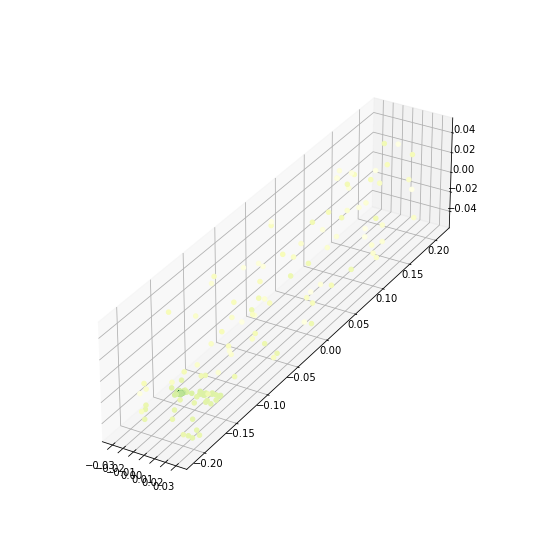

In [6]:
path = resultsDiffuse[1]['x'][:,0,:]
print(resultsDiffuse[0]['L'])
colors = np.arange(len(path))
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect((np.ptp(path[:,0]), np.ptp(path[:,2]), np.ptp(path[:,1])))  # aspect ratio is 1:1:1 in data space
ax.scatter(path[:,0], path[:,2], path[:,1], c=colors, cmap='YlGn', alpha=1)
plt.show()

In [24]:
notWeird = results[1]['n_bounce'][-1][results[1]['n_bounce'][-1]!=0]
minval = min(notWeird)
maxval = max(notWeird)
print(minval, maxval)
logbins = np.logspace(np.log10(minval), np.log10(maxval), num=100)
plt.hist(results[1]['n_bounce'][-1], bins = logbins)
plt.yscale('log')
plt.xscale('log')
plt.axvline(maxval)
plt.show()

NameError: name 'results' is not defined

In [23]:
np.logspace?